# Lab Assignment 2 - Sequence Modelling NLP Part 2

Notebook ini sengaja dibuat simpel:

- `src/task1_text_generator.py` untuk Task 1.
- `src/task2_seq2seq.py` untuk Task 2 dan Task 3.
- `src/optional_task.py` untuk beam search dan pointer-generator.
- Dataset Task 2 memakai IndoSum dari Kaggle untuk text summarization.
- `src/common.py` untuk helper umum.
- `src/sample_data.py` untuk data contoh Task 1.

## Setup

Cell pertama hanya aktif saat notebook dijalankan di Google Colab. Kalau dijalankan lokal, cell ini otomatis skip agar folder `src` lokal tidak tertimpa.

In [12]:
# Colab-only setup. Local Jupyter/VS Code will skip this cell safely.
import importlib.util

if importlib.util.find_spec('google.colab'):
    !wget -q -O repo.zip https://github.com/teranixbq/SequenceModellingNLP_Part2/archive/refs/heads/main.zip
    !unzip -oq repo.zip
    !rm -rf src
    !cp -r SequenceModellingNLP_Part2-main/src src
    !pip install sacrebleu kagglehub
    !rm -rf repo.zip SequenceModellingNLP_Part2-main
else:
    print('Local run: setup skipped.')

In [13]:
import matplotlib.pyplot as plt
import torch
from src.common import calculate_bleu, perplexity, set_seed
from src.optional_task import build_pointer_generator_model, translate_with_beam_search
from src.sample_data import TEXT_CORPUS
from src.task1_text_generator import (
    LSTMTextGenerator,
    SimpleRNNTextGenerator,
    build_char_vocab,
    generate_text,
    make_text_dataloader,
    train_text_generator,
)
from src.task2_seq2seq import (
    build_seq2seq_model,
    build_translation_data,
    make_translation_dataloader,
    train_seq2seq,
    translate_sentence,
)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Dataset Summarization - IndoSum

Dataset Task 2 memakai IndoSum dari Kaggle: `linkgish/indosum`.

File IndoSum berbentuk JSONL, jadi dibaca dengan `pandas.read_json(..., lines=True)`. Artikel dipakai sebagai input dan ringkasan sebagai target.

In [14]:
from pathlib import Path

import kagglehub
import pandas as pd


def flatten_text(value):
    if isinstance(value, list):
        return ' '.join(flatten_text(item) for item in value)
    return str(value)


def limit_words(text, max_words):
    return ' '.join(text.split()[:max_words])


def load_indosum_pairs(max_samples=2000):
    dataset_path = Path(kagglehub.dataset_download('linkgish/indosum'))
    files = sorted(dataset_path.rglob('train.*.jsonl')) or sorted(dataset_path.rglob('*.jsonl'))
    dataframe = pd.concat((pd.read_json(file, lines=True) for file in files), ignore_index=True)
    dataframe = dataframe.head(max_samples)

    sources = dataframe['paragraphs'].apply(lambda value: limit_words(flatten_text(value), 60))
    targets = dataframe['summary'].apply(lambda value: limit_words(flatten_text(value), 25))
    return [(source, target) for source, target in zip(sources, targets) if source and target]


sequence_pairs = load_indosum_pairs(max_samples=2000)
len(sequence_pairs), sequence_pairs[0]

100%|██████████| 94.4M/94.4M [00:02<00:00, 34.7MB/s]

Extracting files...


(2000,
 ('Jakarta , CNN Indonesia - - Dokter Ryan Thamrin , yang terkenal lewat acara Dokter Oz Indonesia , meninggal dunia pada Jumat ( 4 / 8 ) dini hari . Dokter Lula Kamal yang merupakan selebriti sekaligus rekan kerja Ryan menyebut kawannya itu sudah sakit sejak setahun yang lalu . Lula menuturkan , sakit itu membuat Ryan mesti vakum dari',
  'Dokter Lula Kamal yang merupakan selebriti sekaligus rekan kerja Ryan Thamrin menyebut kawannya itu sudah sakit sejak setahun yang lalu . Lula menuturkan , sakit'))

## Task 1 - LSTM Text Generator

Requirement yang dipenuhi:

- memakai `nn.LSTM`,
- training dengan sequence input,
- generate text minimal 100 karakter,
- membandingkan Simple RNN vs LSTM.

In [15]:
char_to_id, id_to_char = build_char_vocab(TEXT_CORPUS)
text_loader = make_text_dataloader(TEXT_CORPUS, char_to_id, sequence_length=60, batch_size=32)

simple_rnn = SimpleRNNTextGenerator(len(id_to_char), embedding_size=48, hidden_size=96).to(device)
lstm_model = LSTMTextGenerator(len(id_to_char), embedding_size=48, hidden_size=96).to(device)

rnn_losses = train_text_generator(simple_rnn, text_loader, epochs=15, learning_rate=0.003, device=device)
lstm_losses = train_text_generator(lstm_model, text_loader, epochs=15, learning_rate=0.003, device=device)

print(f'Simple RNN loss: {rnn_losses[-1]:.4f} | perplexity: {perplexity(rnn_losses[-1]):.2f}')
print(f'LSTM loss      : {lstm_losses[-1]:.4f} | perplexity: {perplexity(lstm_losses[-1]):.2f}')

Simple RNN loss: 0.1134 | perplexity: 1.12
LSTM loss      : 0.1082 | perplexity: 1.11


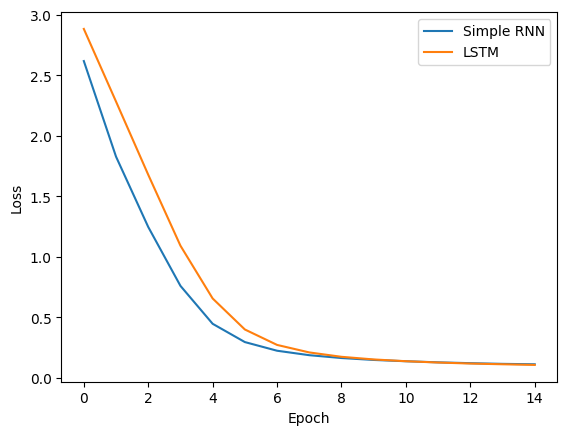

natural language processing studies how computers understand human language.
recurrent neural sent neneran an ltentss ource decoder focus on important source words while producing each target word


In [16]:
plt.plot(rnn_losses, label='Simple RNN')
plt.plot(lstm_losses, label='LSTM')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(generate_text(lstm_model, 'natural language', char_to_id, id_to_char, generated_length=180, device=device))

## Task 2 - Encoder Decoder LSTM

Requirement yang dipenuhi:

- encoder bidirectional LSTM,
- decoder LSTM dengan teacher forcing,
- embedding layer + LSTM,
- `pack_padded_sequence` untuk variable sequence length.

Di task ini, source adalah potongan artikel IndoSum dan target adalah ringkasannya.

In [17]:
data = build_translation_data(sequence_pairs, train_ratio=0.85, seed=42)
source_token_to_id = data['source_token_to_id']
target_token_to_id = data['target_token_to_id']
target_id_to_token = data['target_id_to_token']

train_loader = make_translation_dataloader(
    data['train_pairs'],
    source_token_to_id,
    target_token_to_id,
    batch_size=16,
    shuffle=True,
)

basic_model = build_seq2seq_model(
    source_token_to_id,
    target_token_to_id,
    embedding_size=64,
    hidden_size=96,
    decoder_type='basic',
).to(device)

basic_losses = train_seq2seq(
    basic_model,
    train_loader,
    epochs=40,
    learning_rate=0.002,
    target_pad_id=target_token_to_id['<pad>'],
    device=device,
    teacher_forcing_ratio=0.6,
)

print(f'Encoder-decoder final loss: {basic_losses[-1]:.4f}')

Encoder-decoder final loss: 2.6490


## Task 3 - Bahdanau Attention

Model berikut memakai additive attention dan dapat divisualisasikan.

In [18]:
attention_model = build_seq2seq_model(
    source_token_to_id,
    target_token_to_id,
    embedding_size=64,
    hidden_size=96,
    decoder_type='attention',
).to(device)

attention_losses = train_seq2seq(
    attention_model,
    train_loader,
    epochs=40,
    learning_rate=0.002,
    target_pad_id=target_token_to_id['<pad>'],
    device=device,
    teacher_forcing_ratio=0.6,
)

print(f'Attention model final loss: {attention_losses[-1]:.4f}')

Attention model final loss: 0.0967


In [19]:
test_sources = [source for source, _ in data['test_pairs']]
test_references = [target for _, target in data['test_pairs']]

basic_predictions = [
    translate_sentence(basic_model, source, source_token_to_id, target_id_to_token, device)['translation']
    for source in test_sources
]
attention_predictions = [
    translate_sentence(attention_model, source, source_token_to_id, target_id_to_token, device)['translation']
    for source in test_sources
]

print(f'BLEU without attention: {calculate_bleu(test_references, basic_predictions):.2f}')
print(f'BLEU with attention   : {calculate_bleu(test_references, attention_predictions):.2f}')

BLEU without attention: 0.07
BLEU with attention   : 0.38


ARTICLE: Jakarta , CNN Indonesia - - Perkara panjang yang menimpa Ketua Umum Partai Golkar Setya Novanto alias Setnov kini memasuki babak baru . Ia dilaporkan mengalami kecelakaan mobil di kawasan Kebayoran Lama , Jakarta Selatan . Mobil yang ditumpanginya menabrak tiang lampu di Jalan Permata Berlian , Kompleks Permata Hijau . Peristiwa ini mendadak membuat tiang lampu naik daun .
SUMMARY: kecelakaan yang menimpa ketua umum partai golkar setya novanto di kawasan kebayoran lama , jakarta selatan membuat tiang lampu yang


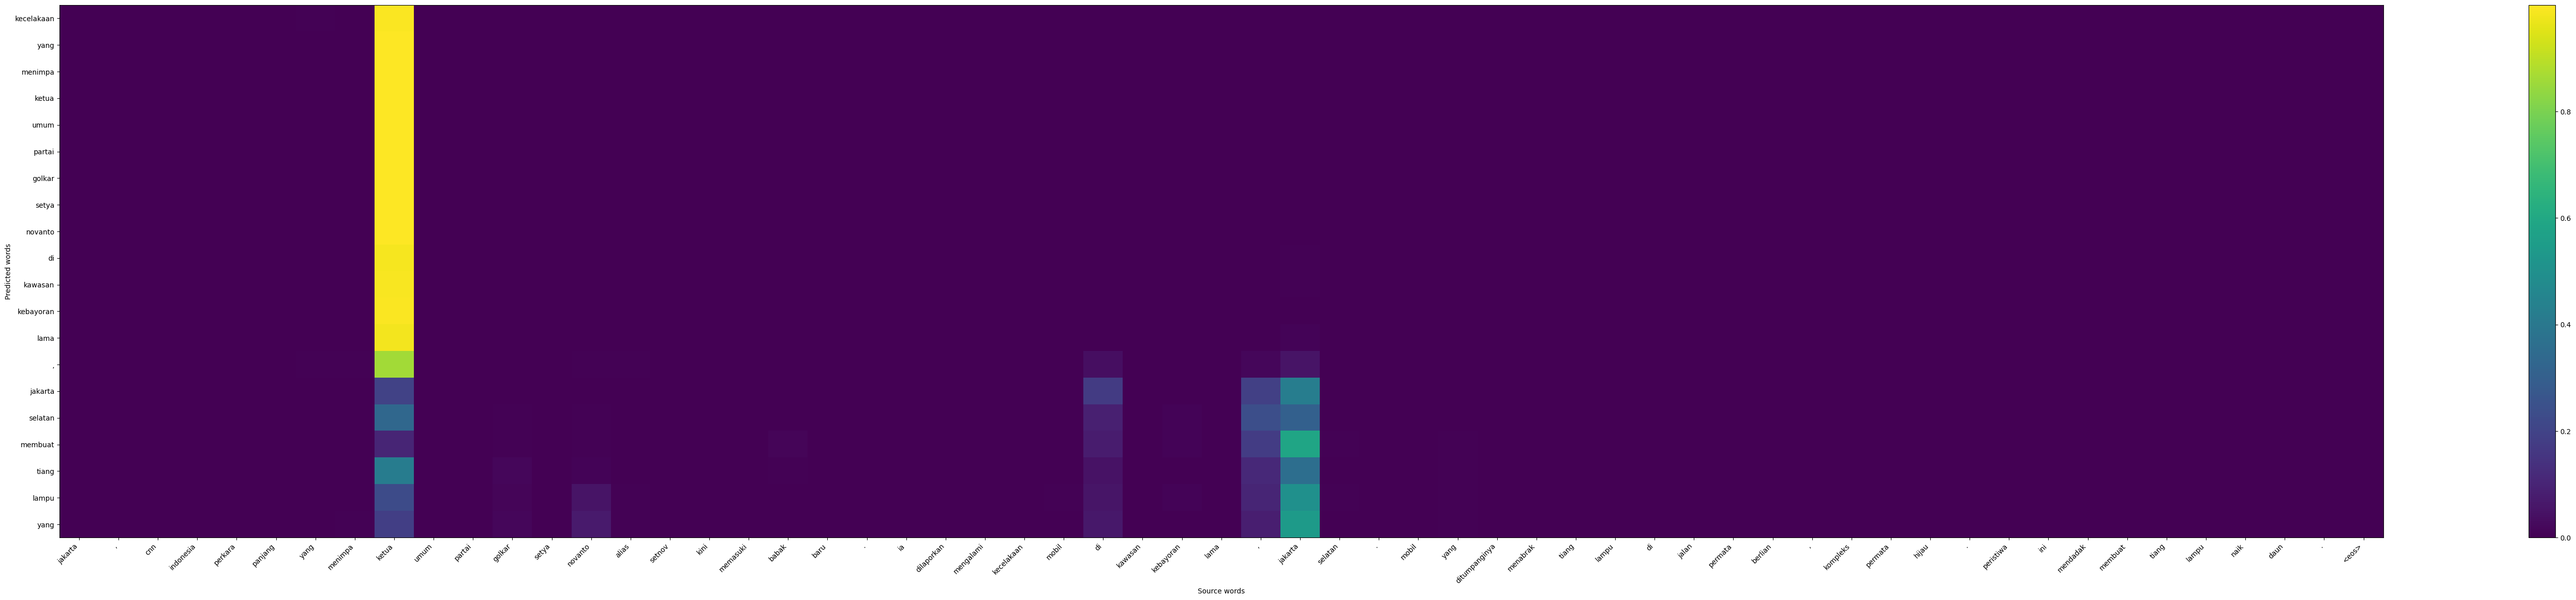

ARTICLE: Cilegon , Banten ( ANTARA News ) - Gladi resik sebagai persiapan terakhir upacara peringatan HUT ke - 72 TNI digelar , di Pantai Indah Kiat , Cilegon , Banten , Selasa . Belasan ribu personel TNI dari ketiga matranya menjadi bagian dari prosesi upacara yang digelar besar-besaran itu . Pusat Penerangan TNI menyatakan , tema pokok pada upacara peringatan
SUMMARY: gladi resik sebagai persiapan terakhir upacara peringatan hut ke 72 tni digelar , di pantai indah kiat , banten ,


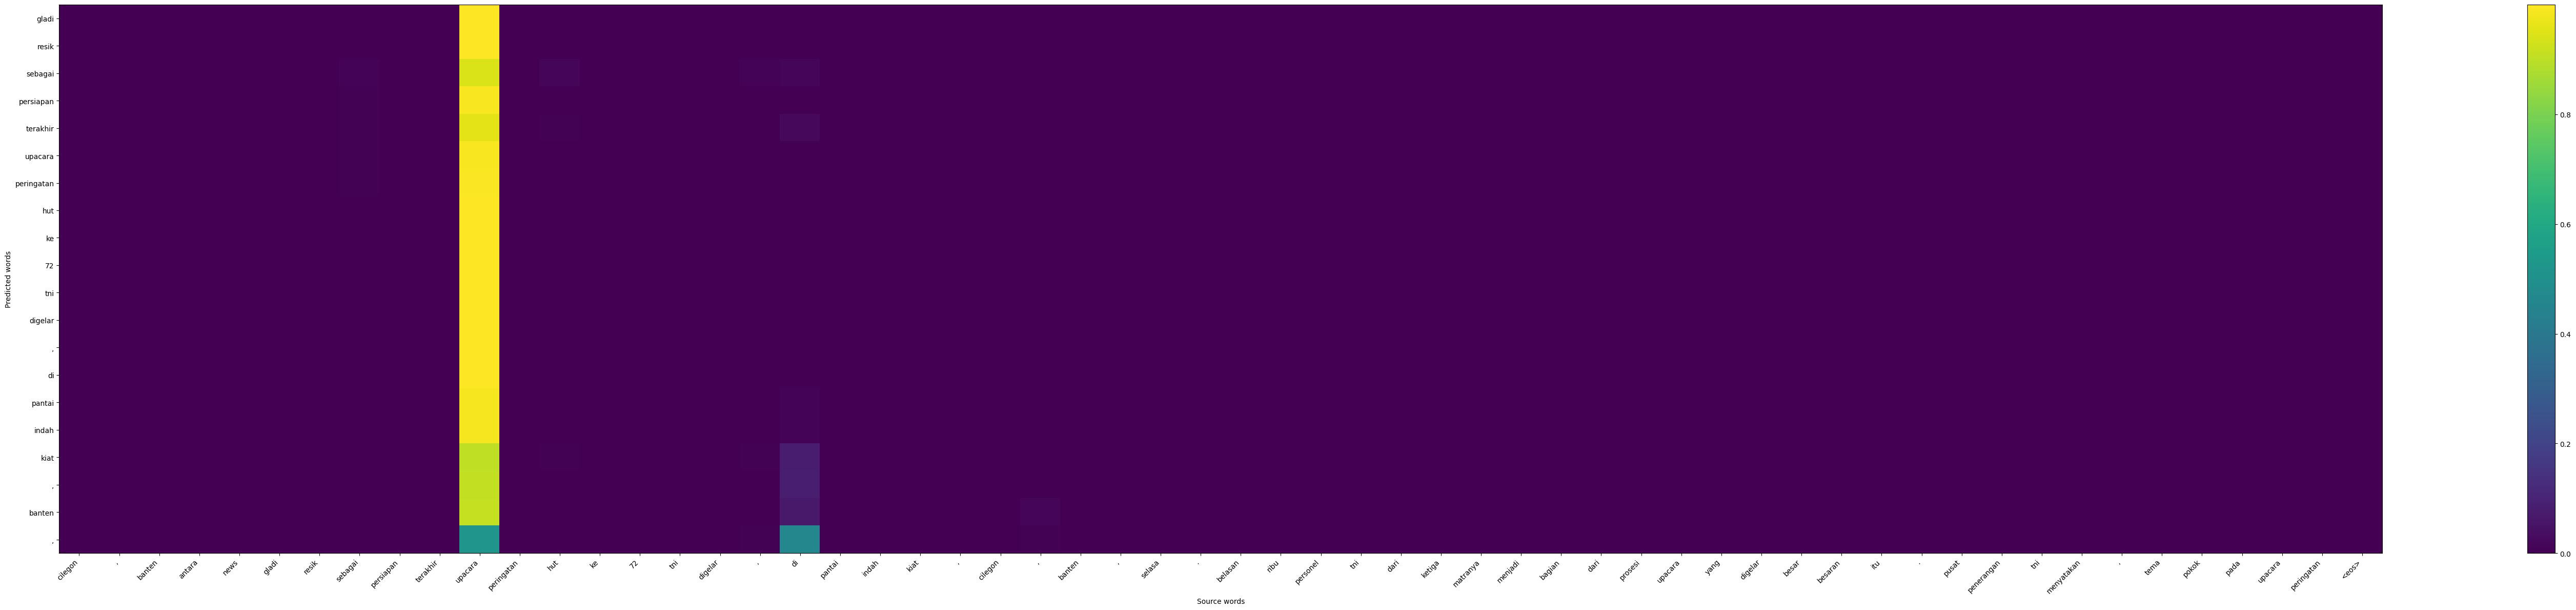

ARTICLE: Instagram kembali menggulirkan pembaruan untuk platform media sosialnya . Dalam giliran update terbaru ini , Instagram mengadopsi sistem urutan komentar milik Facebook yang saling terkait dan mengelompok . Dengan sistem ini , pengguna makin mudah melacak dan mengikuti percakapan di foto dan video tertentu di Instagram . Kini , dengan menjawab komentar di sebuah foto atau video , komentar pengguna
SUMMARY: instagram mengadopsi sistem urutan komentar milik facebook yang saling terkait dan mengelompok . dengan sistem ini , pengguna makin mudah


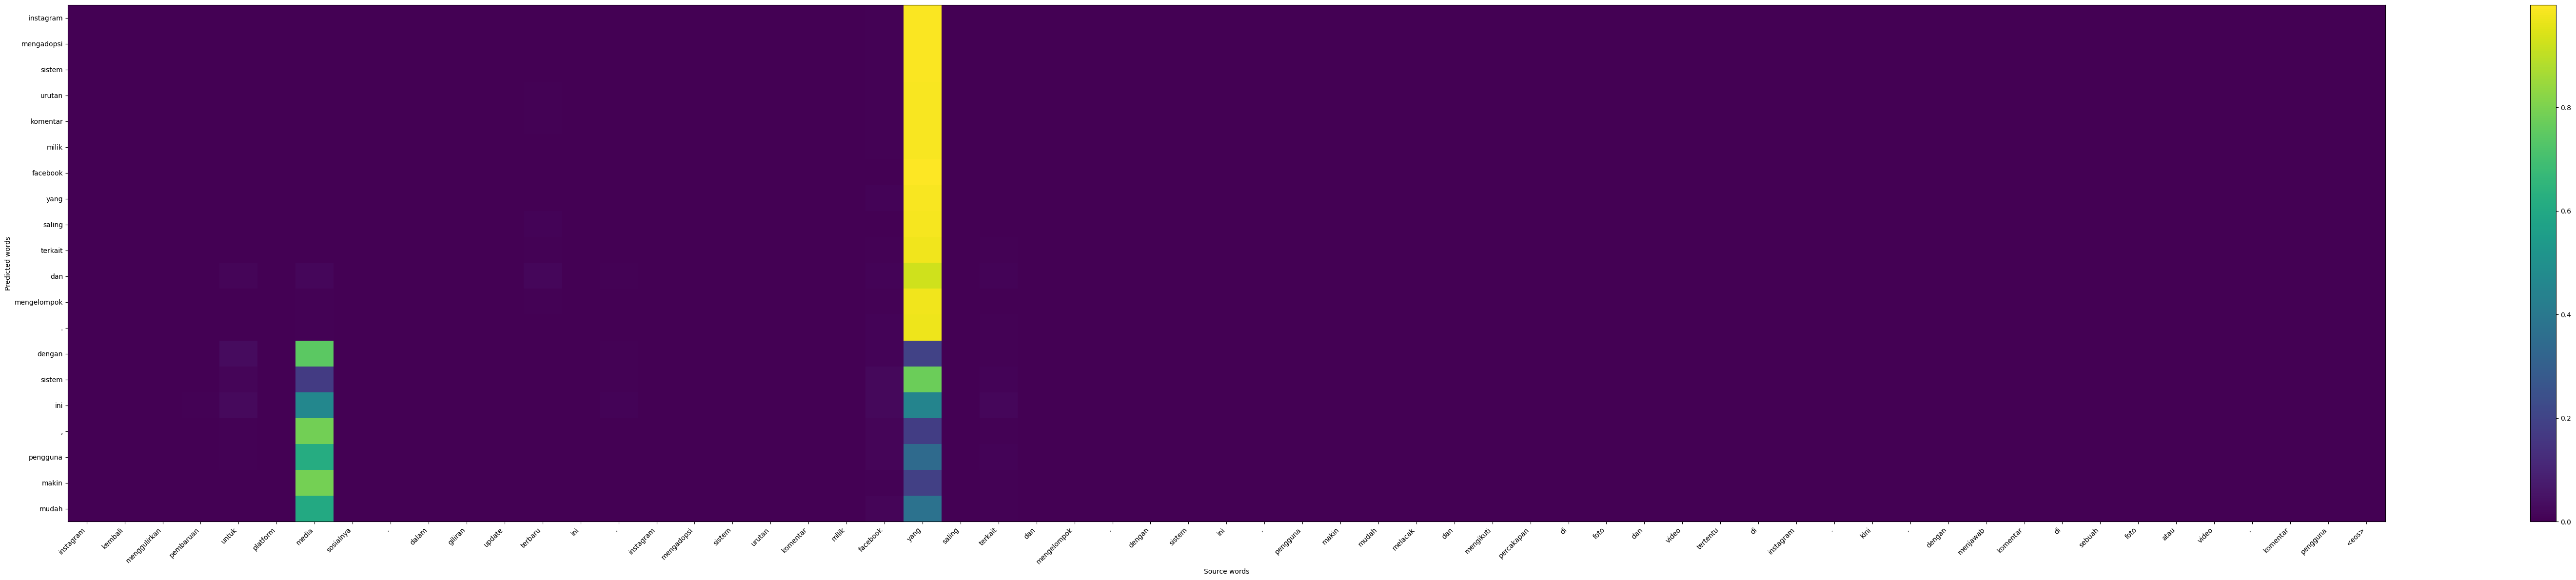

In [20]:
def show_attention(sentence):
    result = translate_sentence(attention_model, sentence, source_token_to_id, target_id_to_token, device)
    attention = result['attention']
    if attention is None:
        print('Model ini tidak punya attention weights.')
        return

    source_tokens = result['source_tokens']
    predicted_tokens = result['predicted_tokens']
    matrix = attention[: len(predicted_tokens), : len(source_tokens)].numpy()

    print('ARTICLE:', sentence)
    print('SUMMARY:', result['translation'])
    plt.figure(figsize=(max(5, len(source_tokens)), max(3, len(predicted_tokens) * 0.6)))
    plt.imshow(matrix, cmap='viridis', aspect='auto')
    plt.xticks(range(len(source_tokens)), source_tokens, rotation=45, ha='right')
    plt.yticks(range(len(predicted_tokens)), predicted_tokens)
    plt.xlabel('Source words')
    plt.ylabel('Predicted words')
    plt.colorbar()
    plt.tight_layout()
    plt.show()

for source, _ in data['train_pairs'][:3]:
    show_attention(source)

## Bonus 1 - Beam Search

Beam search dipakai saat decoding, bukan saat training.

In [21]:
example_sentence = test_sources[0] if test_sources else data['train_pairs'][0][0]

greedy_result = translate_sentence(attention_model, example_sentence, source_token_to_id, target_id_to_token, device)
beam_result = translate_with_beam_search(
    attention_model,
    example_sentence,
    source_token_to_id,
    target_id_to_token,
    device,
    beam_size=3,
)

print('Article:', example_sentence)
print('Greedy summary:', greedy_result['translation'])
print('Beam summary  :', beam_result['translation'])

Article: Jakarta , CNN Indonesia - - Melipat kain batik ternyata bukanlah cara yang tepat saat menyimpannya untuk jangka waktu lama . Apalagi kemudian memberinya pewangi lemari pakaian , bisa - bisa ada warna atau coraknya yang pudar dan kusam . Mengetahui trik penyimpanan batik kemudian menjadi penting agar kain batik tetap awet dan tahan lama . Beberapa tips itu bisa
Greedy summary: film resmi yang tak ingin menghentikan online dan biaya tahun depan . film ini . salah satu satunya yaitu itu
Beam summary  : ditlantas pengusaha film ingin menghentikan online dan biaya tahun depan . film ini . keduanya itu diketahui menonton film yang


## Bonus 2 - Pointer Generator Network

Pointer-generator menggabungkan vocabulary distribution dan copy distribution dari attention weights. Ini berguna saat ada nama orang, lokasi, atau token source yang sebaiknya disalin.

In [22]:
pointer_model = build_pointer_generator_model(
    source_token_to_id,
    target_token_to_id,
    embedding_size=64,
    hidden_size=96,
    copy_map=data['copy_map'],
).to(device)

pointer_losses = train_seq2seq(
    pointer_model,
    train_loader,
    epochs=40,
    learning_rate=0.002,
    target_pad_id=target_token_to_id['<pad>'],
    device=device,
    teacher_forcing_ratio=0.6,
)

pointer_result = translate_with_beam_search(
    pointer_model,
    example_sentence,
    source_token_to_id,
    target_id_to_token,
    device,
    beam_size=3,
)
print(f'Pointer-generator final loss: {pointer_losses[-1]:.4f}')
print('Pointer + beam summary:', pointer_result['translation'])

Pointer-generator final loss: 0.7493
Pointer + beam summary: kain ternyata bukanlah cara yang tepat saat menyimpannya untuk jangka waktu lama . apalagi kemudian
